# Análise Visual — Tráfego Aéreo Brasileiro (ANAC 2000–2025)

Este notebook é **autossuficiente**: ele importa as funções do `pipeline_anac.py`,
executa todo o pipeline ETL (download → amostragem → limpeza → salvamento em Parquet)
e gera as visualizações gráficas.

**Basta executar este notebook** — não é necessário rodar o `pipeline_anac.py` separadamente.

In [1]:
import os
import sys
import warnings

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
from pyspark.sql import DataFrame
from pyspark.sql import functions as F

# Importa as funções do pipeline
sys.path.insert(0, os.getcwd())
from pipeline_anac import (
    download_dataset,
    create_spark_session,
    load_and_sample_data,
    clean_and_transform,
    save_to_parquet,
)

warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.figsize": (12, 6),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.dpi": 100,
})

/home/raynan/Documentos/uvv/processamento-grandes-volumes-dados/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Pipeline ETL — Download, Amostragem, Limpeza e Salvamento

Executa todo o pipeline de dados: baixa o dataset via Kaggle, cria a SparkSession
com limites de memória defensivos, aplica amostragem de 2%, filtra etapas regulares/extras,
trata nulos e salva o resultado em Parquet.

In [2]:
# 1. Download do dataset (kagglehub faz cache — só baixa na 1ª vez)
dataset_path = download_dataset()

# 2. Cria SparkSession com memória limitada (12g de 20g disponíveis)
spark = create_spark_session(driver_memory="12g")

# 3. Leitura do CSV + amostragem de 2%
PARQUET_DIR = os.path.join(os.getcwd(), "output_parquet")
parquet_exists = os.path.isfile(os.path.join(PARQUET_DIR, "_SUCCESS"))

if parquet_exists:
    print("Parquet já existe — carregando dados processados...")
    df = spark.read.parquet(PARQUET_DIR)
else:
    print("Executando pipeline completo (download → limpeza → Parquet)...")
    df_raw = load_and_sample_data(spark, dataset_path, fraction=0.02)

    # 4. Limpeza e transformação
    df = clean_and_transform(df_raw)

    # 5. Salvar em Parquet para reusos futuros
    save_to_parquet(df, PARQUET_DIR)

print(f"\nRegistros: {df.count():,}")
print(f"Colunas ({len(df.columns)}): {df.columns[:10]}...")
df.printSchema()

2026-04-13 23:31:52,618 [INFO] Dataset baixado em: /home/raynan/.cache/kagglehub/datasets/sturarods/anac-national-civil-aviation-agency-2000-2025/versions/1
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/04/13 23:31:55 WARN Utils: Your hostname, raynan-Aspire-A515-54, resolves to a loopback address: 127.0.1.1; using 192.168.15.5 instead (on interface wlp0s20f3)
26/04/13 23:31:55 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/13 23:31:57 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
2026-04-13 23:32:23,337 [INFO] SparkSession criada — driver_memory=12g


Parquet já existe — carregando dados processados...



Registros: 383,662
Colunas (111): ['id_basica', 'id_empresa', 'sg_empresa_icao', 'sg_empresa_iata', 'nm_empresa', 'nm_pais', 'ds_tipo_empresa', 'nr_voo', 'nr_singular', 'id_di']...
root
 |-- id_basica: double (nullable = true)
 |-- id_empresa: integer (nullable = true)
 |-- sg_empresa_icao: string (nullable = true)
 |-- sg_empresa_iata: string (nullable = true)
 |-- nm_empresa: string (nullable = true)
 |-- nm_pais: string (nullable = true)
 |-- ds_tipo_empresa: string (nullable = true)
 |-- nr_voo: integer (nullable = true)
 |-- nr_singular: string (nullable = true)
 |-- id_di: integer (nullable = true)
 |-- cd_di: string (nullable = true)
 |-- ds_di: string (nullable = true)
 |-- ds_grupo_di: string (nullable = true)
 |-- dt_referencia: date (nullable = true)
 |-- nr_ano_referencia: integer (nullable = true)
 |-- nr_semestre_referencia: integer (nullable = true)
 |-- nm_semestre_referencia: string (nullable = true)
 |-- nr_trimestre_referencia: integer (nullable = true)
 |-- nm_trim

## 2. Top 10 Companhias Aéreas por Passageiros Pagos

Identifica as companhias aéreas com maior volume de passageiros pagos na amostra.

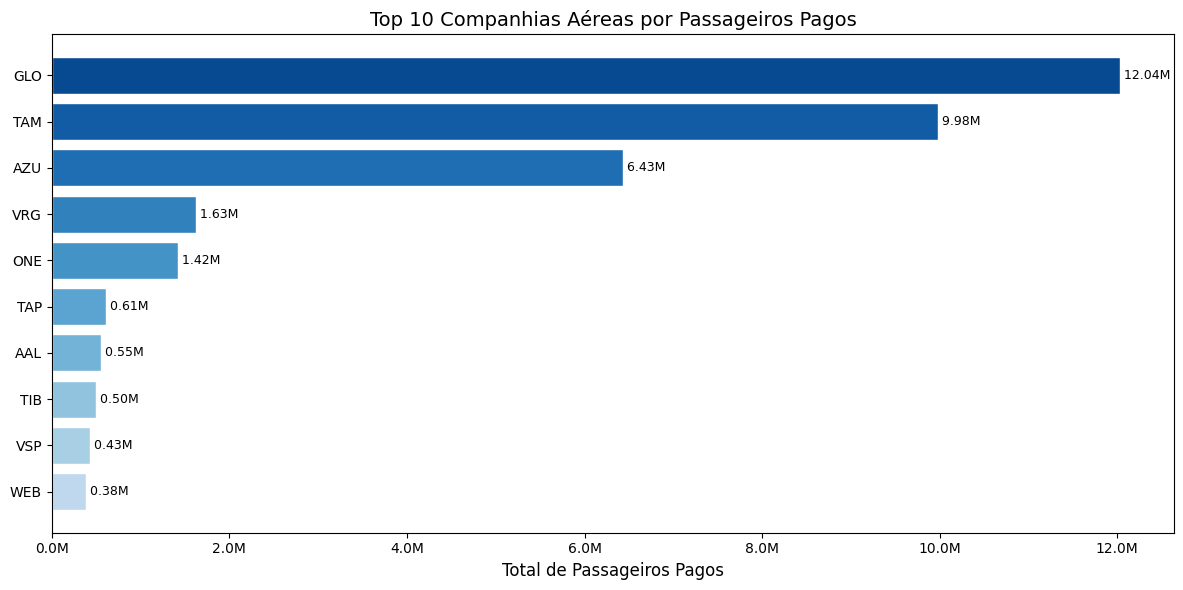

In [3]:
passengers_by_airline = (
    df.groupBy("sg_empresa_icao")
    .agg(F.sum("nr_passag_pagos").alias("total_passag_pagos"))
    .orderBy(F.col("total_passag_pagos").desc())
    .limit(10)
)
pdf_airlines = passengers_by_airline.toPandas()

fig, ax = plt.subplots()
colors = plt.cm.Blues([ 0.9 - i * 0.07 for i in range(len(pdf_airlines))])
bars = ax.barh(
    pdf_airlines["sg_empresa_icao"][::-1],
    pdf_airlines["total_passag_pagos"][::-1],
    color=colors[::-1],
    edgecolor="white",
)
ax.set_xlabel("Total de Passageiros Pagos")
ax.set_title("Top 10 Companhias Aéreas por Passageiros Pagos")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
for bar in bars:
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2, f" {width/1e6:.2f}M",
            va="center", fontsize=9)
plt.tight_layout()
plt.show()

## 3. Top 10 Rotas Mais Movimentadas

Pares de aeródromos (origem → destino) com maior fluxo de passageiros.

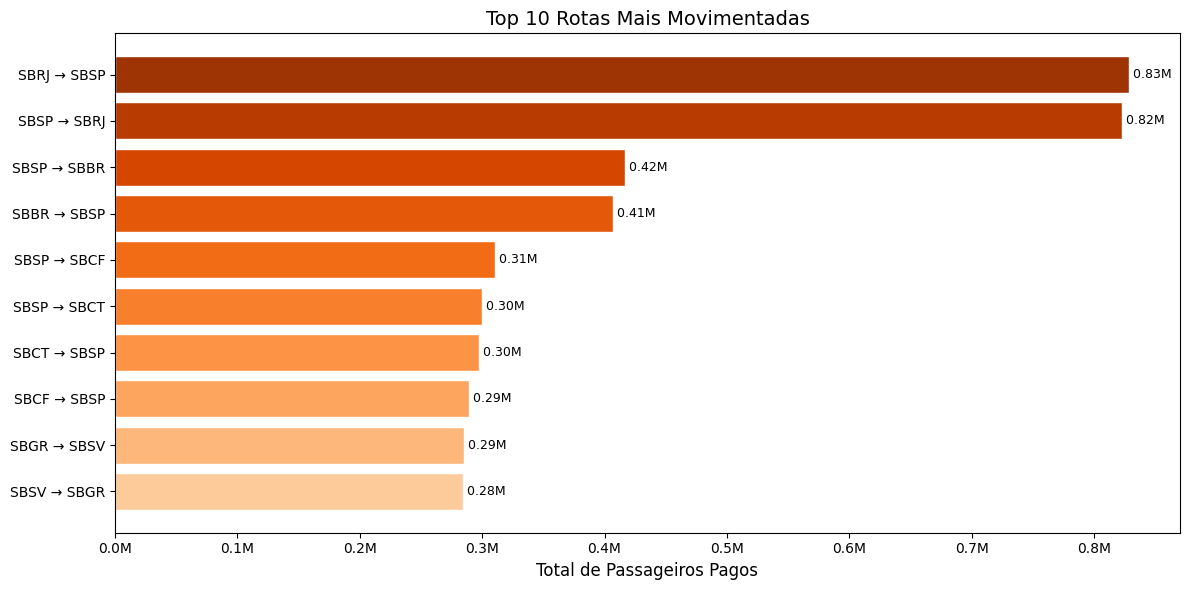

In [4]:
top_routes = (
    df.groupBy("sg_icao_origem", "sg_icao_destino")
    .agg(F.sum("nr_passag_pagos").alias("total_passag_pagos"))
    .orderBy(F.col("total_passag_pagos").desc())
    .limit(10)
)
pdf_routes = top_routes.toPandas()
pdf_routes["rota"] = pdf_routes["sg_icao_origem"] + " → " + pdf_routes["sg_icao_destino"]

fig, ax = plt.subplots()
colors = plt.cm.Oranges([0.9 - i * 0.07 for i in range(len(pdf_routes))])
bars = ax.barh(
    pdf_routes["rota"][::-1],
    pdf_routes["total_passag_pagos"][::-1],
    color=colors[::-1],
    edgecolor="white",
)
ax.set_xlabel("Total de Passageiros Pagos")
ax.set_title("Top 10 Rotas Mais Movimentadas")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
for bar in bars:
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2, f" {width/1e6:.2f}M",
            va="center", fontsize=9)
plt.tight_layout()
plt.show()

## 4. Evolução Anual do Tráfego Aéreo

Série temporal de passageiros pagos e total de voos por ano.

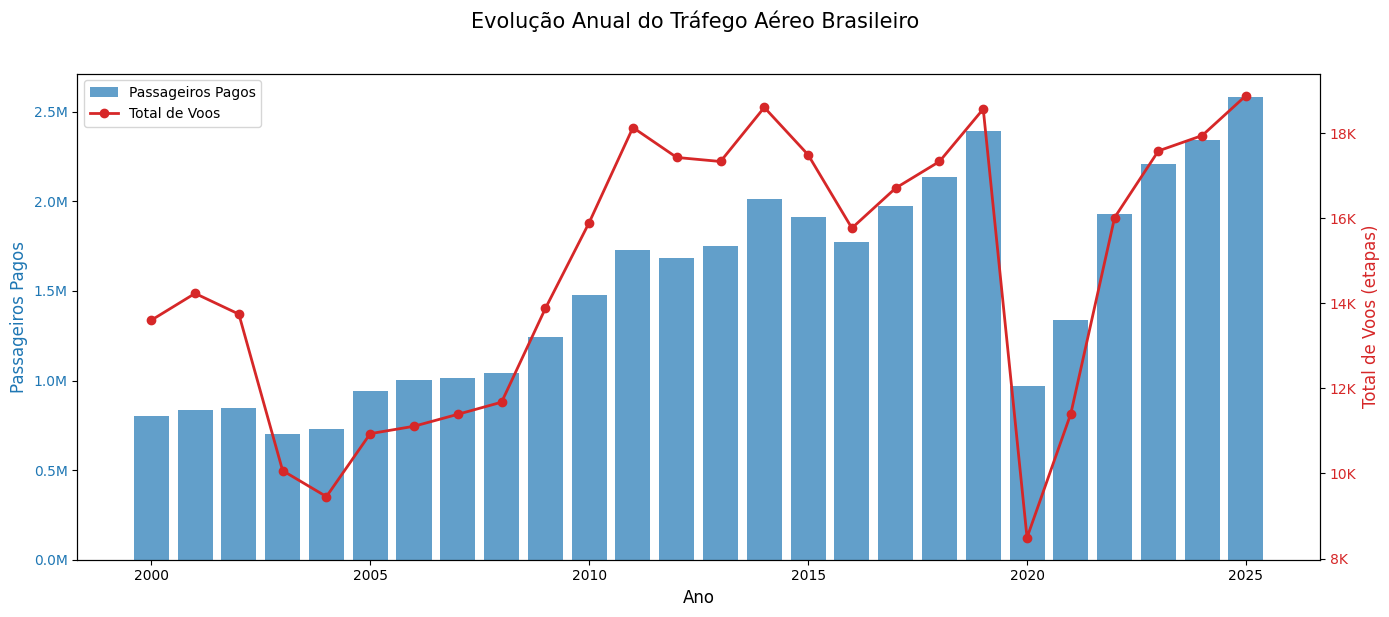

In [5]:
yearly = (
    df.groupBy("nr_ano_referencia")
    .agg(
        F.sum("nr_passag_pagos").alias("total_passag_pagos"),
        F.count("*").alias("total_voos"),
    )
    .orderBy("nr_ano_referencia")
)
pdf_yearly = yearly.toPandas().dropna(subset=["nr_ano_referencia"])
pdf_yearly["nr_ano_referencia"] = pdf_yearly["nr_ano_referencia"].astype(int)

fig, ax1 = plt.subplots(figsize=(14, 6))

color_pass = "#1f77b4"
ax1.bar(pdf_yearly["nr_ano_referencia"], pdf_yearly["total_passag_pagos"],
        color=color_pass, alpha=0.7, label="Passageiros Pagos")
ax1.set_xlabel("Ano")
ax1.set_ylabel("Passageiros Pagos", color=color_pass)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
ax1.tick_params(axis="y", labelcolor=color_pass)

color_voos = "#d62728"
ax2 = ax1.twinx()
ax2.plot(pdf_yearly["nr_ano_referencia"], pdf_yearly["total_voos"],
         color=color_voos, marker="o", linewidth=2, label="Total de Voos")
ax2.set_ylabel("Total de Voos (etapas)", color=color_voos)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))
ax2.tick_params(axis="y", labelcolor=color_voos)

fig.suptitle("Evolução Anual do Tráfego Aéreo Brasileiro", fontsize=15, y=1.02)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
plt.tight_layout()
plt.show()

## 5. Sazonalidade Mensal

Distribuição mensal do número de passageiros pagos, revelando padrões sazonais
(ex.: picos em janeiro e julho — férias).

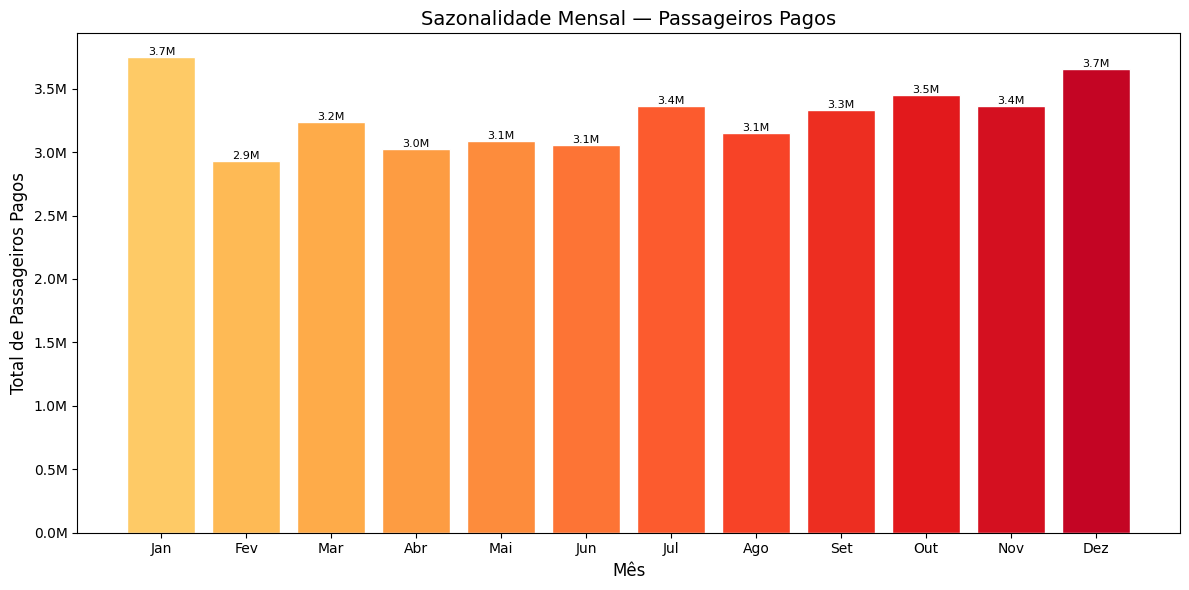

In [6]:
monthly = (
    df.groupBy("nr_mes_referencia")
    .agg(F.sum("nr_passag_pagos").alias("total_passag_pagos"))
    .orderBy("nr_mes_referencia")
)
pdf_monthly = monthly.toPandas().dropna(subset=["nr_mes_referencia"])
pdf_monthly["nr_mes_referencia"] = pdf_monthly["nr_mes_referencia"].astype(int)

MESES = ["Jan", "Fev", "Mar", "Abr", "Mai", "Jun",
         "Jul", "Ago", "Set", "Out", "Nov", "Dez"]
pdf_monthly["mes_nome"] = pdf_monthly["nr_mes_referencia"].apply(
    lambda m: MESES[m - 1] if 1 <= m <= 12 else str(m)
)

fig, ax = plt.subplots()
bars = ax.bar(pdf_monthly["mes_nome"], pdf_monthly["total_passag_pagos"],
              color=plt.cm.YlOrRd([0.3 + 0.05 * i for i in range(len(pdf_monthly))]),
              edgecolor="white")
ax.set_xlabel("Mês")
ax.set_ylabel("Total de Passageiros Pagos")
ax.set_title("Sazonalidade Mensal — Passageiros Pagos")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height, f"{height/1e6:.1f}M",
            ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.show()

## 6. Distribuição Doméstico vs. Internacional

Proporção de passageiros e voos em rotas domésticas vs. internacionais.

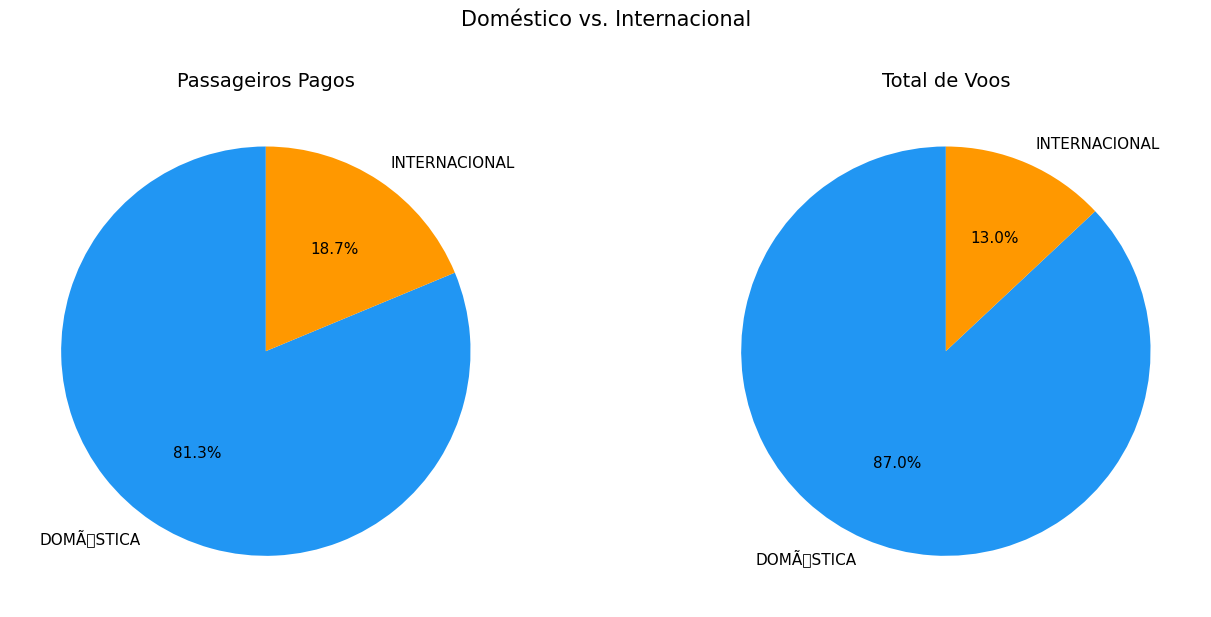

In [7]:
nature = (
    df.groupBy("ds_natureza_etapa")
    .agg(
        F.sum("nr_passag_pagos").alias("total_passag_pagos"),
        F.count("*").alias("total_voos"),
    )
    .orderBy(F.col("total_passag_pagos").desc())
)
pdf_nature = nature.toPandas().dropna(subset=["ds_natureza_etapa"])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

colors = ["#2196F3", "#FF9800", "#4CAF50", "#E91E63"]

ax1.pie(pdf_nature["total_passag_pagos"], labels=pdf_nature["ds_natureza_etapa"],
        autopct="%1.1f%%", colors=colors[:len(pdf_nature)], startangle=90,
        textprops={"fontsize": 11})
ax1.set_title("Passageiros Pagos")

ax2.pie(pdf_nature["total_voos"], labels=pdf_nature["ds_natureza_etapa"],
        autopct="%1.1f%%", colors=colors[:len(pdf_nature)], startangle=90,
        textprops={"fontsize": 11})
ax2.set_title("Total de Voos")

fig.suptitle("Doméstico vs. Internacional", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

## 7. Top 10 Aeroportos Mais Movimentados

Soma de passageiros pagos como origem **e** como destino.

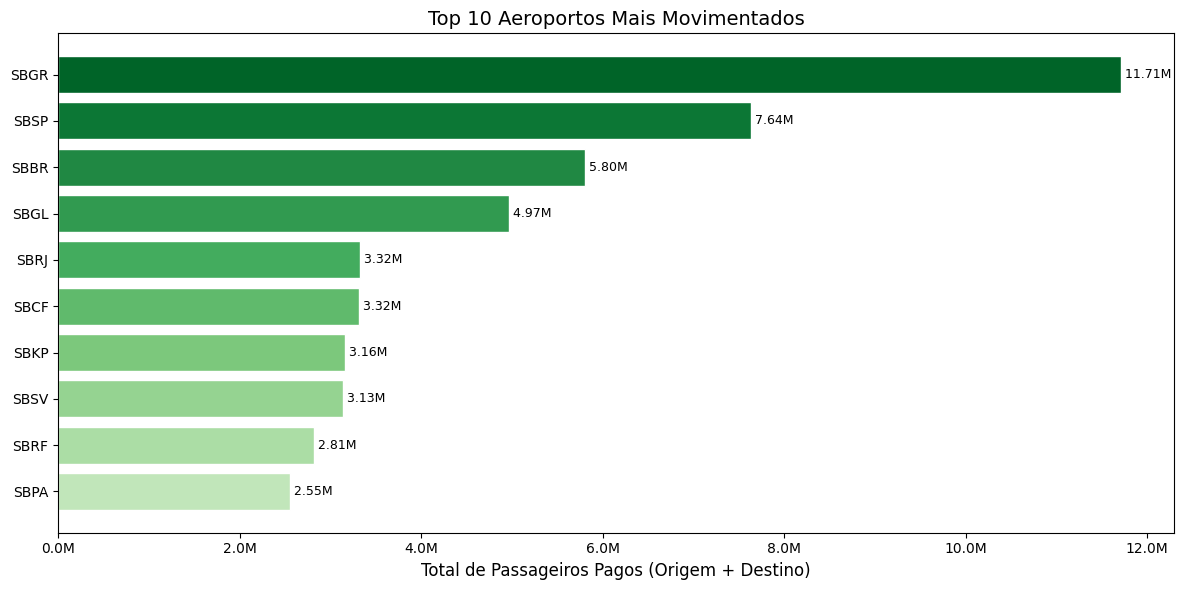

In [8]:
orig = df.select(F.col("sg_icao_origem").alias("aeroporto"), "nr_passag_pagos")
dest = df.select(F.col("sg_icao_destino").alias("aeroporto"), "nr_passag_pagos")

top_airports = (
    orig.union(dest)
    .groupBy("aeroporto")
    .agg(F.sum("nr_passag_pagos").alias("total_passag_pagos"))
    .orderBy(F.col("total_passag_pagos").desc())
    .limit(10)
)
pdf_airports = top_airports.toPandas()

fig, ax = plt.subplots()
colors = plt.cm.Greens([0.9 - i * 0.07 for i in range(len(pdf_airports))])
bars = ax.barh(
    pdf_airports["aeroporto"][::-1],
    pdf_airports["total_passag_pagos"][::-1],
    color=colors[::-1],
    edgecolor="white",
)
ax.set_xlabel("Total de Passageiros Pagos (Origem + Destino)")
ax.set_title("Top 10 Aeroportos Mais Movimentados")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
for bar in bars:
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2, f" {width/1e6:.2f}M",
            va="center", fontsize=9)
plt.tight_layout()
plt.show()

## 8. Market Share das Companhias Aéreas

Participação percentual de cada companhia no total de passageiros pagos.

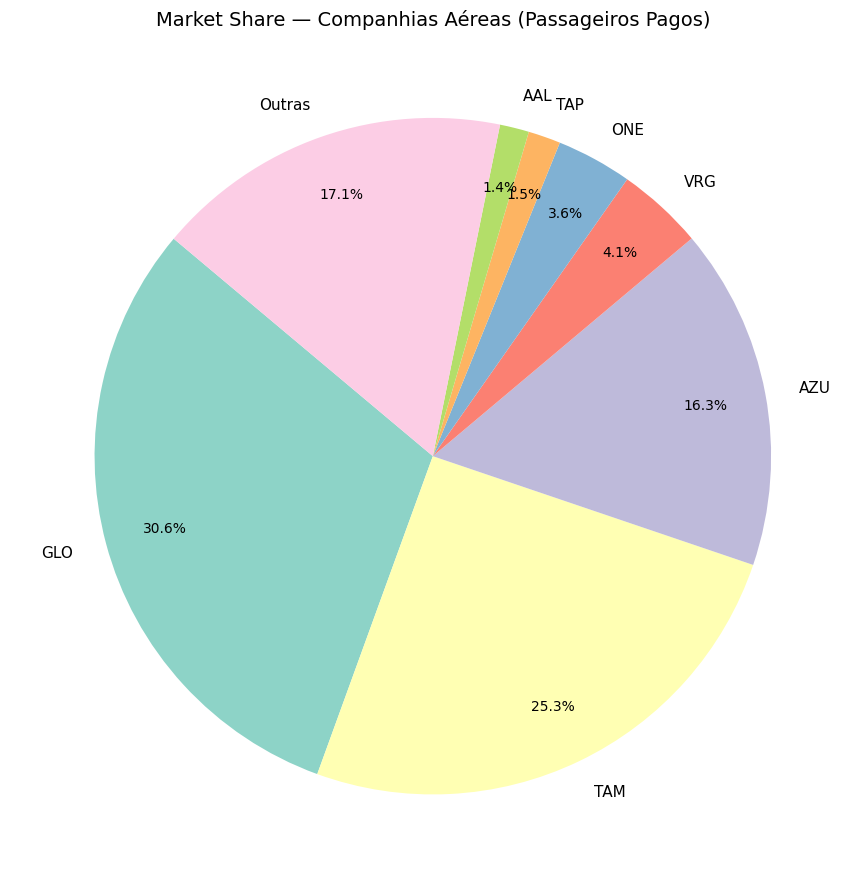

In [9]:
all_airlines = (
    df.groupBy("sg_empresa_icao")
    .agg(F.sum("nr_passag_pagos").alias("total_passag_pagos"))
    .orderBy(F.col("total_passag_pagos").desc())
)
pdf_all = all_airlines.toPandas()

total = pdf_all["total_passag_pagos"].sum()
top_n = 7
pdf_top = pdf_all.head(top_n).copy()
others = total - pdf_top["total_passag_pagos"].sum()
pdf_pie = pd.concat([
    pdf_top[["sg_empresa_icao", "total_passag_pagos"]],
    pd.DataFrame({"sg_empresa_icao": ["Outras"], "total_passag_pagos": [others]}),
], ignore_index=True)

fig, ax = plt.subplots(figsize=(9, 9))
wedges, texts, autotexts = ax.pie(
    pdf_pie["total_passag_pagos"],
    labels=pdf_pie["sg_empresa_icao"],
    autopct="%1.1f%%",
    startangle=140,
    colors=plt.cm.Set3.colors[:len(pdf_pie)],
    textprops={"fontsize": 11},
    pctdistance=0.82,
)
for autotext in autotexts:
    autotext.set_fontsize(10)
ax.set_title("Market Share — Companhias Aéreas (Passageiros Pagos)", fontsize=14)
plt.tight_layout()
plt.show()

## 9. Carga Paga por Companhia Aérea (Top 10)

Volume total de carga paga (kg) transportada pelas 10 maiores operadoras de carga.

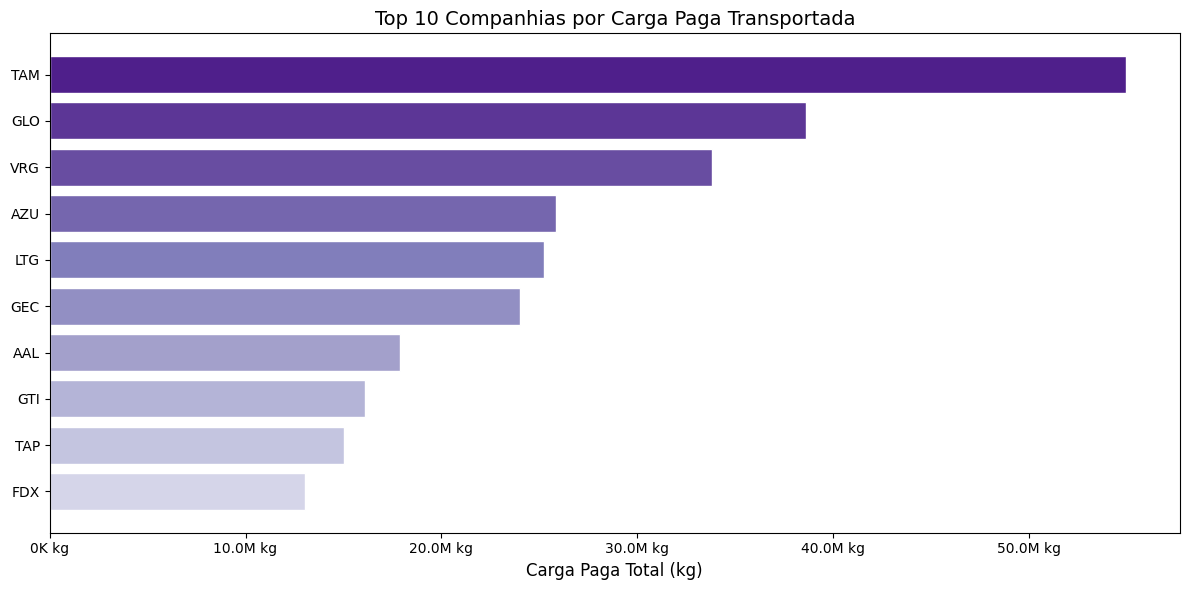

In [10]:
cargo_by_airline = (
    df.groupBy("sg_empresa_icao")
    .agg(F.sum("kg_carga_paga").alias("total_kg_carga"))
    .orderBy(F.col("total_kg_carga").desc())
    .limit(10)
)
pdf_cargo = cargo_by_airline.toPandas()

fig, ax = plt.subplots()
colors = plt.cm.Purples([0.9 - i * 0.07 for i in range(len(pdf_cargo))])
bars = ax.barh(
    pdf_cargo["sg_empresa_icao"][::-1],
    pdf_cargo["total_kg_carga"][::-1],
    color=colors[::-1],
    edgecolor="white",
)
ax.set_xlabel("Carga Paga Total (kg)")
ax.set_title("Top 10 Companhias por Carga Paga Transportada")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"{x/1e6:.1f}M kg" if x >= 1e6 else f"{x/1e3:.0f}K kg"
))
plt.tight_layout()
plt.show()

## 10. Impacto da COVID-19 no Tráfego Aéreo

Compara o volume de passageiros nos anos pré e pós-pandemia (2018–2024),
evidenciando a queda em 2020 e a recuperação gradual.

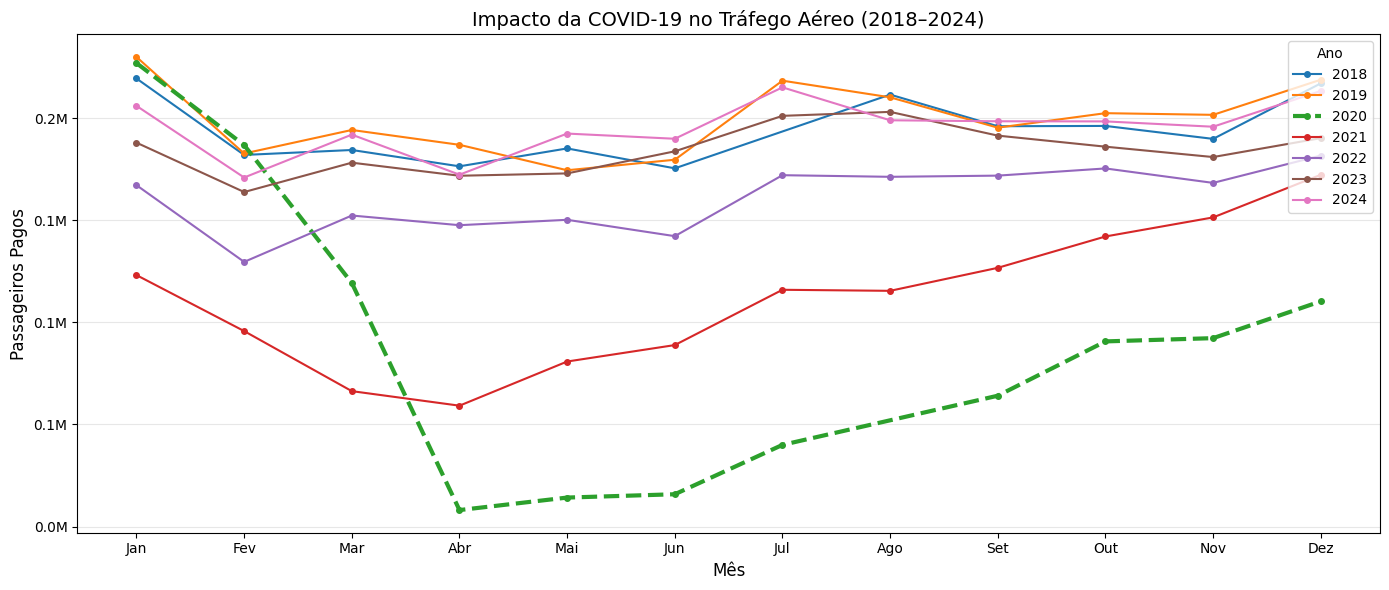

In [11]:
covid_years = (
    df.filter(F.col("nr_ano_referencia").between(2018, 2024))
    .groupBy("nr_ano_referencia", "nr_mes_referencia")
    .agg(F.sum("nr_passag_pagos").alias("total_passag_pagos"))
    .orderBy("nr_ano_referencia", "nr_mes_referencia")
)
pdf_covid = covid_years.toPandas().dropna()
pdf_covid["nr_ano_referencia"] = pdf_covid["nr_ano_referencia"].astype(int)
pdf_covid["nr_mes_referencia"] = pdf_covid["nr_mes_referencia"].astype(int)

MESES = ["Jan", "Fev", "Mar", "Abr", "Mai", "Jun",
         "Jul", "Ago", "Set", "Out", "Nov", "Dez"]

fig, ax = plt.subplots(figsize=(14, 6))
cmap = plt.cm.tab10
for i, year in enumerate(sorted(pdf_covid["nr_ano_referencia"].unique())):
    subset = pdf_covid[pdf_covid["nr_ano_referencia"] == year].sort_values("nr_mes_referencia")
    lw = 3 if year == 2020 else 1.5
    ls = "--" if year == 2020 else "-"
    ax.plot(subset["nr_mes_referencia"], subset["total_passag_pagos"],
            marker="o", markersize=4, linewidth=lw, linestyle=ls,
            color=cmap(i), label=str(year))

ax.set_xticks(range(1, 13))
ax.set_xticklabels(MESES)
ax.set_xlabel("Mês")
ax.set_ylabel("Passageiros Pagos")
ax.set_title("Impacto da COVID-19 no Tráfego Aéreo (2018–2024)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
ax.legend(title="Ano", loc="upper right")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Resumo Estatístico

Tabela resumo com as principais métricas do dataset processado.

In [12]:
summary = df.agg(
    F.count("*").alias("total_registros"),
    F.countDistinct("sg_empresa_icao").alias("companhias_unicas"),
    F.countDistinct("sg_icao_origem").alias("aeroportos_origem"),
    F.countDistinct("sg_icao_destino").alias("aeroportos_destino"),
    F.sum("nr_passag_pagos").alias("total_passag_pagos"),
    F.sum("kg_carga_paga").alias("total_kg_carga"),
    F.min("nr_ano_referencia").alias("ano_inicio"),
    F.max("nr_ano_referencia").alias("ano_fim"),
)

pdf_summary = summary.toPandas().T
pdf_summary.columns = ["Valor"]
pdf_summary.index.name = "Métrica"
pdf_summary

,Valor
Métrica,
total_registros,383662.0
companhias_unicas,159.0
aeroportos_origem,428.0
aeroportos_destino,439.0
total_passag_pagos,39386967.0
total_kg_carga,494912952.0
ano_inicio,2000.0
ano_fim,2025.0


In [13]:
spark.stop()
print("SparkSession encerrada.")

SparkSession encerrada.
